In [329]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics  import accuracy_score, confusion_matrix, classification_report , precision_score, recall_score, f1_score

In [289]:
df = pd.read_csv("adult.csv")

In [290]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [291]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [292]:
df.shape

(48842, 15)

In [293]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [294]:
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [295]:
df.duplicated().sum()

np.int64(52)

In [296]:
df.drop_duplicates(inplace=True)

In [297]:
df["education"].unique()

array(['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th',
       'Prof-school', '7th-8th', 'Bachelors', 'Masters', 'Doctorate',
       '5th-6th', 'Assoc-voc', '9th', '12th', '1st-4th', 'Preschool'],
      dtype=object)

In [298]:
df["marital-status"].unique()

array(['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced',
       'Separated', 'Married-spouse-absent', 'Married-AF-spouse'],
      dtype=object)

In [299]:
df["workclass"].unique()

array(['Private', 'Local-gov', '?', 'Self-emp-not-inc', 'Federal-gov',
       'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [300]:
df["occupation"].unique()

array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv', '?',
       'Other-service', 'Prof-specialty', 'Craft-repair', 'Adm-clerical',
       'Exec-managerial', 'Tech-support', 'Sales', 'Priv-house-serv',
       'Transport-moving', 'Handlers-cleaners', 'Armed-Forces'],
      dtype=object)

In [301]:
df["relationship"].unique()

array(['Own-child', 'Husband', 'Not-in-family', 'Unmarried', 'Wife',
       'Other-relative'], dtype=object)

In [302]:
df["race"].unique()

array(['Black', 'White', 'Asian-Pac-Islander', 'Other',
       'Amer-Indian-Eskimo'], dtype=object)

In [303]:
df["gender"].unique()

array(['Male', 'Female'], dtype=object)

In [304]:
df["native-country"].unique()

array(['United-States', '?', 'Peru', 'Guatemala', 'Mexico',
       'Dominican-Republic', 'Ireland', 'Germany', 'Philippines',
       'Thailand', 'Haiti', 'El-Salvador', 'Puerto-Rico', 'Vietnam',
       'South', 'Columbia', 'Japan', 'India', 'Cambodia', 'Poland',
       'Laos', 'England', 'Cuba', 'Taiwan', 'Italy', 'Canada', 'Portugal',
       'China', 'Nicaragua', 'Honduras', 'Iran', 'Scotland', 'Jamaica',
       'Ecuador', 'Yugoslavia', 'Hungary', 'Hong', 'Greece',
       'Trinadad&Tobago', 'Outlying-US(Guam-USVI-etc)', 'France',
       'Holand-Netherlands'], dtype=object)

In [305]:
df["income"].unique()

array(['<=50K', '>50K'], dtype=object)

In [306]:
df.replace("?", np.nan, inplace=True)

In [307]:
df.isna().sum()

,0
age,0
workclass,2795
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2805
relationship,0
race,0
gender,0


In [308]:
df["workclass"].fillna(df["workclass"].mode()[0], inplace=True)

/tmp/ipykernel_1915/893266844.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["workclass"].fillna(df["workclass"].mode()[0], inplace=True)


In [309]:
df["occupation"].fillna(df["occupation"].mode()[0], inplace=True)

/tmp/ipykernel_1915/3987520725.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["occupation"].fillna(df["occupation"].mode()[0], inplace=True)


In [310]:
df["native-country"].fillna(df["native-country"].mode()[0], inplace=True)

/tmp/ipykernel_1915/1064367851.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["native-country"].fillna(df["native-country"].mode()[0], inplace=True)


In [311]:
x = df.iloc[:, : -1]
y = df["income"]

In [369]:
y.value_counts()

,count
income,
0,37109
1,11681


In [312]:
categorical_columns = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "gender",
    "native-country"
]

In [313]:
x = pd.get_dummies(x, columns=categorical_columns, drop_first=True, dtype=int)

In [314]:
y = y.map(
    {
        "<=50K": 0,
        ">50K": 1
    }
)

In [315]:
x.isna().sum()

,0
age,0
fnlwgt,0
educational-num,0
capital-gain,0
capital-loss,0
...,...
native-country_Thailand,0
native-country_Trinadad&Tobago,0
native-country_United-States,0
native-country_Vietnam,0


**Scaling**

In [317]:
numeric_columns = [
    "age",
    "fnlwgt",
    "educational-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

In [318]:
scaler = MinMaxScaler()

In [319]:
scaler.fit(x[numeric_columns])

MinMaxScaler()

In [320]:
x[numeric_columns] = scaler.transform(x[numeric_columns])

In [321]:
x.isna().sum()

,0
age,0
fnlwgt,0
educational-num,0
capital-gain,0
capital-loss,0
...,...
native-country_Thailand,0
native-country_Trinadad&Tobago,0
native-country_United-States,0
native-country_Vietnam,0


**Data slipting  for test and train**

In [395]:
x_train, x_test, y_train, y_test = train_test_split(x, y , test_size=0.2, random_state=60)

**Model training** - logistical Regression

In [412]:
lr = LogisticRegression( max_iter=1000, class_weight="balanced"
    )

In [413]:
lr.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [414]:
accuracy_score(y_test, lr.predict(x_test))

0.8029309284689485

In [415]:
confusion_matrix(y_test, lr.predict(x_test))

array([[5860, 1582],
       [ 341, 1975]])

<Axes: >

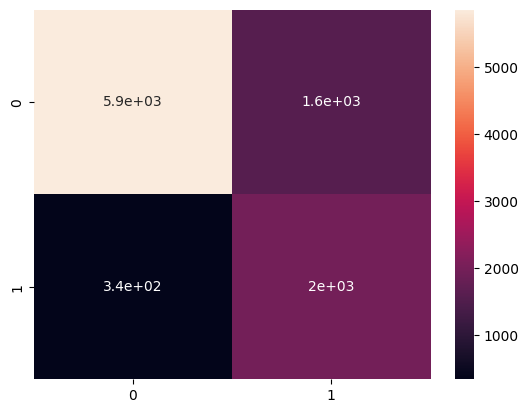

In [416]:
sns.heatmap(confusion_matrix(y_test, lr.predict(x_test)), annot=True)

In [417]:
precision_score(y_test, lr.predict(x_test))

0.5552431824571268

In [418]:
recall_score(y_test, lr.predict(x_test))

0.8527633851468048

In [419]:
f1_score(y_test, lr.predict(x_test))

0.6725693853226631

In [420]:
import pickle

In [424]:
with open("model.pkl", "wb") as file:
    pickle.dump(lr , file)

In [426]:
with open("adult_features.pkl", "wb") as file:
    pickle.dump(x_train.columns.tolist(), file)


In [427]:
with open("adult_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [429]:
from google.colab import files

files.download("model.pkl")
files.download("adult_features.pkl")
files.download("adult_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>